EN ESTE NOTEBOOK:
- Entrenamos con el algoritmo SOM. Este entrenamiento lo hacemos con los tamaños 8x8, 10x10 y 12x12
- Evaluamos Quantization error (menor = mejor) y Topographic error (cercano a 0 = mejor)
- Buscamos la mejor combinación de variables mediante búsqueda de subconjuntos de 2, 3,4 y 5 variables, optimizando el Silhouette Score para k = 2, 3, 4 y 5. Las 3 mejores combinaciones por tamaño de grupo se evalúan en los tres tamaños de SOM.
- Clusterizamos los nodos que nos salen en SOM y evaluamos el Silhouette Score. 
- Visualización, descripción de clústeres y comparación con k-Means de reunion8

### Conceptos clave
- **SOM organiza** los datos en una rejilla donde nodos cercanos significan perfiles similares
- Cada nodo = vector de características ("paciente prototipo")
- El SOM **NO da clusters directamente** → luego aplicamos K-Means sobre los nodos
- **QE**: distancia media de cada paciente a su BMU (Best Matching Unit) → menor = mejor
- **TE**: % de pacientes cuyo 1.º y 2.º BMU no son vecinos → cercano a 0 = buena topología


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1. Carga y preparación de datos

In [3]:
# Dataset principal (imputado) 
df_imp = pd.read_csv('imputado.csv')

# Como se consideran las variables 'plgf_MoM', 'ratio_MoM' y 'sflt1_MoM' y hasta ahora estábamos trabajando con los biomarcadores,
# tenemos que aplicar la transformación de MoM a estas variables.

def calcular_mom_variables(df):
    df = df.copy()
    # Definimos las condiciones basadas en 'eg_deter_sflt1_plgf'
    condiciones = [
        (df['eg_deter_sflt1_plgf'] >= 10) & (df['eg_deter_sflt1_plgf'] < 15), # 10 a 14.99
        (df['eg_deter_sflt1_plgf'] >= 15) & (df['eg_deter_sflt1_plgf'] < 20), # 15 a 19.99
        (df['eg_deter_sflt1_plgf'] >= 20) & (df['eg_deter_sflt1_plgf'] < 24),
        (df['eg_deter_sflt1_plgf'] >= 24) & (df['eg_deter_sflt1_plgf'] < 29),
        (df['eg_deter_sflt1_plgf'] >= 29) & (df['eg_deter_sflt1_plgf'] < 34),
        (df['eg_deter_sflt1_plgf'] >= 34) & (df['eg_deter_sflt1_plgf'] < 37),
        (df['eg_deter_sflt1_plgf'] >= 37)
]

    # Divisores para cada columna
    div_ratio = [24.8, 10.5, 4.92, 3.06, 3.75, 9.03, 19.6]
    div_sflt1 = [1328, 1355, 1299, 1355, 1742, 2552, 3485]
    div_plgf  = [52.6, 135, 264, 465, 471, 284, 191]

    # Aplicamos np.select para obtener el divisor correspondiente a cada fila
    # Si no cumple ninguna condición, devuelve NaN (np.nan)
    df['ratio_MoM'] = df['ratio_sflt1_plgf'] / np.select(condiciones, div_ratio, default=np.nan)
    df['sflt1_MoM'] = df['valor_sflt1'] / np.select(condiciones, div_sflt1, default=np.nan)
    df['plgf_MoM']  = df['valor_plgf'] / np.select(condiciones, div_plgf, default=np.nan)

    return df

df_imp_clust = calcular_mom_variables(df_imp)

variables_a_borrar = ['ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf']
df_imp_clust = df_imp_clust.drop(columns=variables_a_borrar, errors='ignore')

# Datos de ccografía (sin imputar, solo para descripción posterior)
df_eco_raw = pd.read_csv('datos.csv')

# Datos de scores
df_cat_raw = pd.read_excel('variables_CARDIOMOM.xlsx')

In [4]:
# Categorización de scores (idéntica a reunion8)

scl_mapping = {'Nada': 0, 'Muy poco': 1, 'Poco': 2, 'Bastante': 3, 'Mucho': 4}

def cat_regicor_dieta(score):
    if pd.isna(score): return np.nan
    if score < 23: return "Baja adherencia"
    elif 23 <= score <= 29: return "Adherencia moderada"
    else: return "Alta adherencia"

def cat_regicor_actividad(met):
    if pd.isna(met): return np.nan
    if met < 500: return "Actividad física baja"
    elif 500 <= met <= 1000: return "Actividad física moderada"
    else: return "Actividad física alta"

def cat_pss14(score):
    if pd.isna(score): return np.nan
    if score <= 13: return "Nivel de estrés bajo"
    elif 14 <= score <= 26: return "Nivel de estrés moderado"
    elif 27 <= score <= 40: return "Nivel de estrés alto"
    else: return "Nivel de estrés muy alto"

def cat_mfe30(score):
    if pd.isna(score): return np.nan
    if score < 8: return "Rendimiento de memoria óptimo"
    elif 9 <= score <= 35: return "Función normal (lapsus leves)"
    elif 36 <= score <= 50: return "Deterioro leve"
    else: return "Disfunción moderada-grave"

def cat_scl90r(t_score):
    if pd.isna(t_score): return np.nan
    if t_score >= 80: return "Patología severa"
    elif t_score >= 65: return "EN RIESGO"
    else: return "Normal / Sin riesgo"

df_cat_raw['Cat_Dieta']     = df_cat_raw['Score total'].apply(cat_regicor_dieta)
df_cat_raw['Cat_Actividad'] = df_cat_raw['Act física TOTAL (MET/semana)'].apply(cat_regicor_actividad)
df_cat_raw['Cat_Estres']    = df_cat_raw['Score'].apply(cat_pss14)
df_cat_raw['Cat_Memoria']   = df_cat_raw['Score.1'].apply(cat_mfe30)

# SCL-90-R: calcular T-score a partir de los ítems
scl_items_cols = df_cat_raw.loc[:, 'Dolores de cabeza':'Pensar que en mi cabeza hay algo que no funciona bien'].columns
df_scl_numeric = df_cat_raw[scl_items_cols].replace(scl_mapping).apply(pd.to_numeric, errors='coerce')
df_cat_raw['SCL90_IGS_Raw'] = df_scl_numeric.mean(axis=1)
df_cat_raw['SCL90_T_Score'] = df_cat_raw['SCL90_IGS_Raw'].apply(
    lambda raw: 50 + 10 * ((raw - 0.17) / 0.11) if not pd.isna(raw) else np.nan
)
df_cat_raw['Cat_SCL90R'] = df_cat_raw['SCL90_T_Score'].apply(cat_scl90r)

df_cat = df_cat_raw[['ID', 'Cat_Dieta', 'Cat_Actividad', 'Cat_Estres', 'Cat_Memoria', 'Cat_SCL90R']].copy()
print(f'df_cat: {df_cat.shape}')
df_cat.head(3)

df_cat: (608, 6)


,ID,Cat_Dieta,Cat_Actividad,Cat_Estres,Cat_Memoria,Cat_SCL90R
0,1,Adherencia moderada,Actividad física alta,Nivel de estrés alto,Función normal (lapsus leves),Patología severa
1,2,Adherencia moderada,Actividad física alta,Nivel de estrés moderado,Rendimiento de memoria óptimo,Patología severa
2,3,Baja adherencia,Actividad física alta,Nivel de estrés moderado,NaN,NaN


In [5]:
# Variables de ecografía (solo para descripción, sin imputar)
vars_eco = [
    'diam_telediastolico', 'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole',
    'pared_posterior_vi_diastole', 'diam_ai', 'ai_volumen', 'ad_volumen', 'tapse',
    'e_mitral', 'e_e', 'gc_tsvi', 'urato_acidourico'
]
df_eco = df_eco_raw[['id'] + vars_eco].copy()
print(f'df_eco: {df_eco.shape}')

df_eco: (459, 14)


In [6]:
# Variables numéricas para SOM (mismas que reunion8)
numericas_cols = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto',
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 'ratio_MoM'
]

df_num = df_imp_clust[['id'] + numericas_cols].dropna(subset=numericas_cols).copy()

scaler = StandardScaler()
X_arr = scaler.fit_transform(df_num[numericas_cols])
df_scaled = pd.DataFrame(X_arr, columns=numericas_cols, index=df_num.index)
df_scaled['id'] = df_num['id'].values

print(f'Dataset escalado: {df_scaled.shape}')

Dataset escalado: (458, 17)


# 2. Funciones auxiliares para SOM

In [7]:
def topographic_error(som, data):
    """
    TE: proporción de puntos cuyo 1.º y 2.º BMU NO son adyacentes en la rejilla.
    Adyacente = distancia de Chebyshev <= 1 (incluye diagonales).
    """
    n_rows, n_cols, _ = som.get_weights().shape
    error = 0
    for x in data:
        bmu1 = som.winner(x)
        dists = np.linalg.norm(
            som.get_weights().reshape(-1, data.shape[1]) - x, axis=1
        ).reshape(n_rows, n_cols)
        dists_copy = dists.copy()
        dists_copy[bmu1] = np.inf
        bmu2 = np.unravel_index(np.argmin(dists_copy), dists_copy.shape)
        # Chebyshev distance > 1 → no son vecinos
        if max(abs(bmu1[0] - bmu2[0]), abs(bmu1[1] - bmu2[1])) > 1:
            error += 1
    return error / len(data)


def train_som(X, size, sigma=None, lr=0.5, n_iter=10000, seed=1234):
    """Entrena un SOM cuadrado size×size. sigma por defecto = size/2."""
    if sigma is None:
        sigma = size / 2
    som = MiniSom(size, size, X.shape[1],
                  sigma=sigma, learning_rate=lr,
                  neighborhood_function='gaussian',
                  random_seed=seed)
    if X.shape[1] >= 2:
        som.pca_weights_init(X)
    else:
        som.random_weights_init(X)
    som.train(X, n_iter, verbose=False)
    return som


def evaluate_som(som, X):
    """Devuelve (QE, TE) del SOM entrenado."""
    qe = som.quantization_error(X)
    te = topographic_error(som, X)
    return qe, te


def cluster_som_nodes(som, X, k):
    """
    1. Extrae vectores de peso de todos los nodos.
    2. Aplica K-Means sobre los nodos → cada nodo recibe etiqueta de cluster.
    3. Asigna etiqueta de cluster a cada paciente vía su BMU.
    Retorna: (labels_pacientes, labels_nodos)
    """
    n_rows, n_cols, n_features = som.get_weights().shape
    weights = som.get_weights().reshape(-1, n_features)  # (n_nodos, n_features)

    km = KMeans(n_clusters=k, n_init=10, random_state=1234)
    labels_nodes = km.fit_predict(weights)

    labels_patients = np.array([
        labels_nodes[som.winner(x)[0] * n_cols + som.winner(x)[1]]
        for x in X
    ])
    return labels_patients, labels_nodes


def silhouette_som(X, som, k):
    """Silhouette sobre pacientes usando clusters derivados del SOM."""
    labels, _ = cluster_som_nodes(som, X, k)
    unique, counts = np.unique(labels, return_counts=True)
    if len(unique) < 2 or any(counts < 2):
        return np.nan
    return silhouette_score(X, labels)

print('Funciones SOM definidas.')

Funciones SOM definidas.


# 3. Entrenamiento SOM con todas las variables numéricas (3 tamaños)

Primero entrenamos con todas las variables numéricas disponibles para obtener una línea base.

In [8]:
X_full = df_scaled[numericas_cols].values
SOM_SIZES = [8, 10, 12]
N_ITER    = 10000

baseline_results = []


soms_baseline = {}
for sz in SOM_SIZES:
    som = train_som(X_full, size=sz, n_iter=N_ITER)
    qe, te = evaluate_som(som, X_full)
    soms_baseline[sz] = som
    baseline_results.append({'Tamaño': f'{sz}×{sz}', 'QE': round(qe, 4), 'TE': round(te, 4)})
    

df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)

,Tamaño,QE,TE
0,8×8,2.5238,0.0284
1,10×10,2.5040,0.0240
2,12×12,2.4838,0.0371


## Silhouette (nodos clusterizados, k = 2..5)

In [9]:
k_range = [2, 3, 4, 5]
rows = []

for sz in SOM_SIZES:
    for k in k_range:
        sil = silhouette_som(X_full, soms_baseline[sz], k)
        rows.append({'Tamaño': f'{sz}×{sz}', 'k': k, 'Silhouette': round(sil, 4)})

df_sil_baseline = pd.DataFrame(rows)
display(df_sil_baseline.pivot(index='k', columns='Tamaño', values='Silhouette'))

Tamaño,10×10,12×12,8×8
k,,,
2,0.1879,0.1879,0.1628
3,0.1419,0.1478,0.1460
4,0.0680,0.0795,0.0645
5,0.0903,0.0853,0.0801


# 4. Búsqueda de la mejor combinación de variables

**Algoritmo**: búsqueda exhaustiva por tamaño de subconjunto (grupos de 2 y 3 variables).
- Se evalúan todas las combinaciones posibles para cada tamaño de grupo
- Para cada combinación se entrena un SOM 10×10 con 1.000 iteraciones (búsqueda rápida)
- Se calcula el Silhouette Score para k = 2..5 y se guarda el mejor k
- Se devuelven las 3 mejores combinaciones por tamaño de grupo ordenadas por Silhouette
- El apartado 5 refinará estas combinaciones con 10.000 iteraciones y los 3 tamaños de SOM

In [10]:
from itertools import combinations

SEARCH_SIZE   = 10    # SOM 10×10 para la búsqueda
N_ITER_SEARCH = 1000  # iteraciones reducidas para acelerar la búsqueda
TOP_N         = 3     # top 3 combinaciones por tamaño de grupo
K_SEARCH      = [2, 3, 4, 5]  # valores de k para Silhouette
GROUP_SIZES   = [2, 3, 4, 5]        # tamaños de grupo a explorar

all_results = []  # acumula todas las combinaciones evaluadas

for group_size in GROUP_SIZES:
    combis_size = list(combinations(numericas_cols, group_size))
    print(f"Grupos de {group_size} variables: {len(combis_size)} combinaciones")

    for i, vars_c in enumerate(combis_size):
        vars_c = list(vars_c)
        X_sub = df_scaled[vars_c].values

        # Entrenar SOM rápido
        som = train_som(X_sub, size=SEARCH_SIZE, n_iter=N_ITER_SEARCH)
        qe, te = evaluate_som(som, X_sub)

        # Calcular mejor Silhouette entre los k probados
        best_sil = -1
        best_k   = None
        for k in K_SEARCH:
            sil = silhouette_som(X_sub, som, k)
            if not np.isnan(sil) and sil > best_sil:
                best_sil = sil
                best_k   = k

        all_results.append({
            'group_size'    : group_size,
            'num_variables' : group_size,
            'variables'     : vars_c,
            'qe'            : round(qe, 4),
            'te'            : round(te, 4),
            'silhouette'    : round(best_sil, 4) if best_k is not None else np.nan,
            'best_k'        : best_k
        })

        if (i + 1) % 20 == 0:
            print(f"  Evaluadas {i+1}/{len(combis_size)}...")

    print(f"Completado grupo de {group_size} variables.")

print("BÚSQUEDA COMPLETADA")


Grupos de 2 variables: 120 combinaciones
  Evaluadas 20/120...
  Evaluadas 40/120...
  Evaluadas 60/120...
  Evaluadas 80/120...
  Evaluadas 100/120...
  Evaluadas 120/120...
Completado grupo de 2 variables.
Grupos de 3 variables: 560 combinaciones
  Evaluadas 20/560...
  Evaluadas 40/560...
  Evaluadas 60/560...
  Evaluadas 80/560...
  Evaluadas 100/560...
  Evaluadas 120/560...
  Evaluadas 140/560...
  Evaluadas 160/560...
  Evaluadas 180/560...
  Evaluadas 200/560...
  Evaluadas 220/560...
  Evaluadas 240/560...
  Evaluadas 260/560...
  Evaluadas 280/560...
  Evaluadas 300/560...
  Evaluadas 320/560...
  Evaluadas 340/560...
  Evaluadas 360/560...
  Evaluadas 380/560...
  Evaluadas 400/560...
  Evaluadas 420/560...
  Evaluadas 440/560...
  Evaluadas 460/560...
  Evaluadas 480/560...
  Evaluadas 500/560...
  Evaluadas 520/560...
  Evaluadas 540/560...
  Evaluadas 560/560...
Completado grupo de 3 variables.
Grupos de 4 variables: 1820 combinaciones
  Evaluadas 20/1820...
  Evaluadas 4

In [25]:
# Mostrar top3 por tamaño de grupo y construir top_combis
df_all_results = pd.DataFrame(all_results)
top_combis = []

print("TOP 3 COMBINACIONES POR TAMAÑO DE GRUPO (ordenadas por Silhouette)")
for group_size in GROUP_SIZES:
    sub  = df_all_results[df_all_results['group_size'] == group_size]
    top3 = sub.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False).head(TOP_N)
    print(f"Grupos de {group_size} variables")
    display(top3[['variables', 'qe', 'te', 'silhouette', 'best_k']].reset_index(drop=True))
    top_combis.extend(top3.to_dict('records'))

print(f"Total combinaciones seleccionadas para evaluación detallada: {len(top_combis)}")


TOP 3 COMBINACIONES POR TAMAÑO DE GRUPO (ordenadas por Silhouette)
Grupos de 2 variables


,variables,qe,te,silhouette,best_k
0,"[apgar_5min, apgar_10min]",0.0485,0.0066,0.9624,5
1,"[apgar_10min, ratio_MoM]",0.1017,0.2183,0.9273,3
2,"[apgar_1min, apgar_10min]",0.0839,0.0000,0.8803,2


Grupos de 3 variables


,variables,qe,te,silhouette,best_k
0,"[apgar_5min, apgar_10min, ratio_MoM]",0.1757,0.2162,0.8779,2
1,"[apgar_1min, apgar_5min, apgar_10min]",0.1371,0.0000,0.8660,2
2,"[apgar_1min, apgar_5min, ratio_MoM]",0.2357,0.0218,0.8658,2


Grupos de 4 variables


,variables,qe,te,silhouette,best_k
0,"[apgar_1min, apgar_5min, apgar_10min, ratio_MoM]",0.3044,0.0699,0.8509,2
1,"[apgar_5min, apgar_10min, sflt1_MoM, ratio_MoM]",0.2814,0.0284,0.8213,3
2,"[apgar_1min, apgar_10min, sflt1_MoM, ratio_MoM]",0.3589,0.0153,0.8204,2


Grupos de 5 variables


,variables,qe,te,silhouette,best_k
0,"[apgar_1min, apgar_5min, apgar_10min, sflt1_MoM, ratio_MoM]",0.4405,0.0022,0.7911,2
1,"[apgar_1min, apgar_10min, eg_parto, sflt1_MoM, ratio_MoM]",0.5554,0.0153,0.7555,2
2,"[apgar_1min, apgar_5min, apgar_10min, eg_parto, ratio_MoM]",0.5245,0.0786,0.7461,2


Total combinaciones seleccionadas para evaluación detallada: 12


# 5. Evaluación de las mejores combinaciones en los 3 tamaños

Para cada combinación encontrada, entrenamos SOM con 8×8, 10×10 y 12×12 con más iteraciones.

In [26]:
N_ITER_EVAL = 10000
evaluation_results = []
trained_soms = {}  # (combi_idx, size) -> som
scaled_subsets = {}  # combi_idx -> (X_sc, scaler_sc)

for ci, combi in enumerate(top_combis):
    vars_c = combi['variables']
    X_sub = df_scaled[vars_c].values
    sc = StandardScaler()
    X_sc = sc.fit_transform(X_sub)
    scaled_subsets[ci] = (X_sc, sc, vars_c)

    print(f'\nCombinación {ci+1}: {vars_c}')
    print(f"  {'Tamaño':<10} {'QE':>10} {'TE':>10}")

    for sz in SOM_SIZES:
        som = train_som(X_sc, size=sz, n_iter=N_ITER_EVAL)
        qe, te = evaluate_som(som, X_sc)
        trained_soms[(ci, sz)] = som
        evaluation_results.append({
            'combi': ci + 1,
            'variables': vars_c,
            'num_vars': len(vars_c),
            'tamaño': f'{sz}×{sz}',
            'size': sz,
            'QE': round(qe, 5),
            'TE': round(te, 5)
        })
        print(f'  {sz}×{sz}       {qe:>10.5f} {te:>10.5f}')

df_eval = pd.DataFrame(evaluation_results)
print('\nTabla resumen')
display(df_eval[['combi', 'tamaño', 'QE', 'TE', 'num_vars', 'variables']])


Combinación 1: ['apgar_5min', 'apgar_10min']
  Tamaño             QE         TE
  8×8          0.03878    0.00000
  10×10          0.03506    0.00218
  12×12          0.03358    0.00218

Combinación 2: ['apgar_10min', 'ratio_MoM']
  Tamaño             QE         TE
  8×8          0.08044    0.10044
  10×10          0.07513    0.06114
  12×12          0.07449    0.15502

Combinación 3: ['apgar_1min', 'apgar_10min']
  Tamaño             QE         TE
  8×8          0.08521    0.00437
  10×10          0.06932    0.00218
  12×12          0.06537    0.00873

Combinación 4: ['apgar_5min', 'apgar_10min', 'ratio_MoM']
  Tamaño             QE         TE
  8×8          0.16029    0.00000
  10×10          0.15132    0.12227
  12×12          0.14507    0.19869

Combinación 5: ['apgar_1min', 'apgar_5min', 'apgar_10min']
  Tamaño             QE         TE
  8×8          0.14577    0.00000
  10×10          0.12533    0.00218
  12×12          0.12295    0.00218

Combinación 6: ['apgar_1min', 'apgar_5

,combi,tamaño,QE,TE,num_vars,variables
0,1,8×8,0.03878,0.00000,2,"[apgar_5min, apgar_10min]"
1,1,10×10,0.03506,0.00218,2,"[apgar_5min, apgar_10min]"
2,1,12×12,0.03358,0.00218,2,"[apgar_5min, apgar_10min]"
3,2,8×8,0.08044,0.10044,2,"[apgar_10min, ratio_MoM]"
4,2,10×10,0.07513,0.06114,2,"[apgar_10min, ratio_MoM]"
5,2,12×12,0.07449,0.15502,2,"[apgar_10min, ratio_MoM]"
6,3,8×8,0.08521,0.00437,2,"[apgar_1min, apgar_10min]"
7,3,10×10,0.06932,0.00218,2,"[apgar_1min, apgar_10min]"
8,3,12×12,0.06537,0.00873,2,"[apgar_1min, apgar_10min]"
9,4,8×8,0.16029,0.00000,3,"[apgar_5min, apgar_10min, ratio_MoM]"


# 6. Clusterización de nodos y Silhouette

Para cada combinación y tamaño de SOM aplicamos K-Means sobre los vectores de peso de los nodos y calculamos Silhouette sobre los pacientes.

In [27]:
k_range = [2, 3, 4, 5]
sil_results = []

for ci in range(len(top_combis)):
    X_sc, _, vars_c = scaled_subsets[ci]
    for sz in SOM_SIZES:
        som = trained_soms[(ci, sz)]
        for k in k_range:
            sil = silhouette_som(X_sc, som, k)
            labels, labels_nodes = cluster_som_nodes(som, X_sc, k)
            unique, counts = np.unique(labels, return_counts=True)
            sil_results.append({
                'combi': ci + 1,
                'tamaño': f'{sz}×{sz}',
                'size': sz,
                'k': k,
                'Silhouette': round(sil, 5) if not np.isnan(sil) else np.nan,
                'distribución': dict(zip([f'G{u}' for u in unique], counts.tolist())),
                'variables': vars_c
            })

df_sil = pd.DataFrame(sil_results)

print('SILHOUETTE POR COMBINACIÓN, TAMAÑO Y K')
print('(clusterización K-Means sobre nodos del SOM)')
display(df_sil.pivot_table(index=['combi', 'k'], columns='tamaño', values='Silhouette'))

SILHOUETTE POR COMBINACIÓN, TAMAÑO Y K
(clusterización K-Means sobre nodos del SOM)


tamaño     10×10    12×12      8×8
combi k                           
1     2  0.91836  0.91836  0.91836
      3  0.91479  0.91479  0.91973
      4  0.95404  0.95406  0.95215
      5  0.95997  0.96253  0.95997
2     2  0.90780  0.91082  0.91145
      3  0.92730  0.92730  0.92594
      4  0.91914  0.89445  0.91400
      5  0.88453  0.89886  0.91716
3     2  0.88147  0.88142  0.88147
      3  0.86848  0.87111  0.84546
      4  0.86480  0.86539  0.86296
      5  0.86129  0.86093  0.86119
4     2  0.88039  0.87793  0.87793
      3  0.88612  0.88914  0.88805
      4  0.86720  0.86734  0.86730
      5  0.86946  0.85887  0.86678
5     2  0.86608  0.86608  0.86599
      3  0.84491  0.83720  0.84491
      4  0.81606  0.83268  0.81787
      5  0.81576  0.82721  0.81998
6     2  0.85267  0.84620  0.84620
      3  0.80263  0.80566  0.76954
      4  0.77662  0.77457  0.77309
      5  0.76704  0.76640  0.76709
7     2  0.84254  0.84166  0.85035
      3  0.76936  0.81226  0.77026
      4  0.77476  0.76522  0.77911
      5  0.78114  0.77754  0.78709
8     2  0.82315  0.82315  0.82315
      3  0.82522  0.82522  0.82388
      4  0.70292  0.75867  0.71043
      5  0.69234  0.68918  0.69047
9     2  0.81421  0.79962  0.80296
      3  0.78784  0.79376  0.79416
      4  0.61799  0.63572  0.65374
      5  0.61661  0.60859  0.58857
10    2  0.79725  0.79671  0.80007
      3  0.69896  0.69395  0.72987
      4  0.70724  0.64846  0.69721
      5  0.68384  0.64540  0.64775
11    2  0.73170  0.74331  0.74837
      3  0.37391  0.36266  0.69944
      4  0.39454  0.38105  0.33642
      5  0.31140  0.33315  0.34130
12    2  0.75885  0.75394  0.73401
      3  0.63876  0.56757  0.41123
      4  0.42740  0.40971  0.44544
      5  0.38479  0.43974  0.39964

In [28]:
# Mejor combinación global
best_row = df_sil.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print('MEJOR RESULTADO GLOBAL:')
print(f"  Combinación {best_row['combi']}  |  Tamaño {best_row['tamaño']}  |  k={best_row['k']}")
print(f"  Silhouette = {best_row['Silhouette']:.5f}")
print(f"  Variables  = {best_row['variables']}")
print(f"  Distribución = {best_row['distribución']}")

MEJOR RESULTADO GLOBAL:
  Combinación 1  |  Tamaño 12×12  |  k=5
  Silhouette = 0.96253
  Variables  = ['apgar_5min', 'apgar_10min']
  Distribución = {'G0': 11, 'G1': 393, 'G2': 7, 'G3': 30, 'G4': 17}


# 7. Visualizaciones

Usamos la mejor combinación (mayor Silhouette) para generar las visualizaciones.

In [29]:
# Seleccionar el mejor SOM
best_ci   = int(best_row['combi']) - 1
best_sz   = int(best_row['size'])
best_k    = int(best_row['k'])
best_som  = trained_soms[(best_ci, best_sz)]
X_best, _, vars_best = scaled_subsets[best_ci]

labels_best, labels_nodes_best = cluster_som_nodes(best_som, X_best, best_k)

print(f'SOM seleccionado: {best_sz}×{best_sz} | Variables: {vars_best} | k={best_k}')
print(f'Distribución de pacientes por cluster: {dict(zip(*np.unique(labels_best, return_counts=True)))}')

SOM seleccionado: 12×12 | Variables: ['apgar_5min', 'apgar_10min'] | k=5
Distribución de pacientes por cluster: {np.int32(0): np.int64(11), np.int32(1): np.int64(393), np.int32(2): np.int64(7), np.int32(3): np.int64(30), np.int32(4): np.int64(17)}


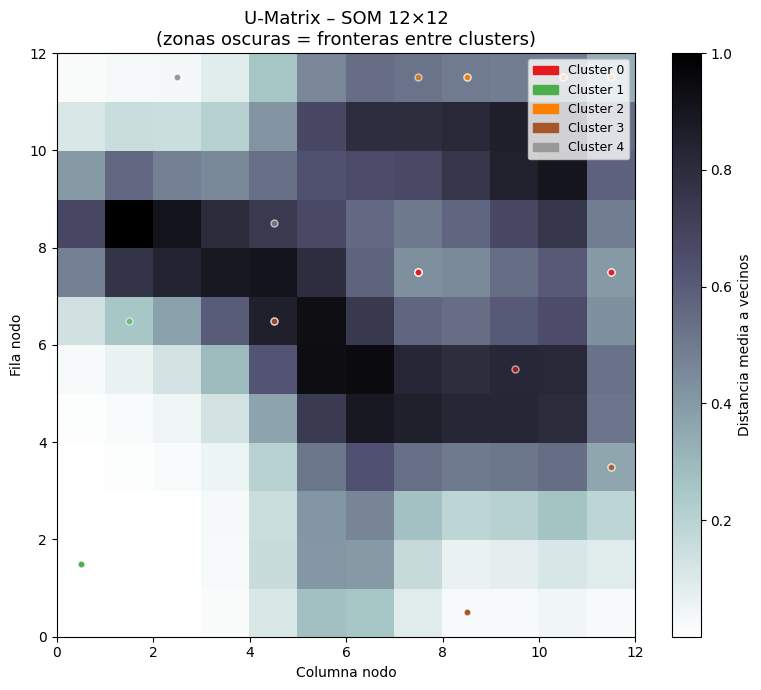

In [30]:
#  U-matrix (mapa de distancias entre nodos vecinos)
fig, ax = plt.subplots(figsize=(8, 7))
umat = best_som.distance_map().T
im = ax.pcolor(umat, cmap='bone_r')
plt.colorbar(im, ax=ax, label='Distancia media a vecinos')
ax.set_title(f'U-Matrix – SOM {best_sz}×{best_sz}\n(zonas oscuras = fronteras entre clusters)', fontsize=13)
ax.set_xlabel('Columna nodo')
ax.set_ylabel('Fila nodo')

# Superponer marcadores de pacientes
colors = plt.cm.Set1(np.linspace(0, 1, best_k))
for x, label in zip(X_best, labels_best):
    w = best_som.winner(x)
    ax.plot(w[0] + 0.5, w[1] + 0.5, 'o',
            markerfacecolor=colors[label], markeredgecolor='white',
            markersize=5, alpha=0.6)

handles = [mpatches.Patch(color=colors[i], label=f'Cluster {i}') for i in range(best_k)]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

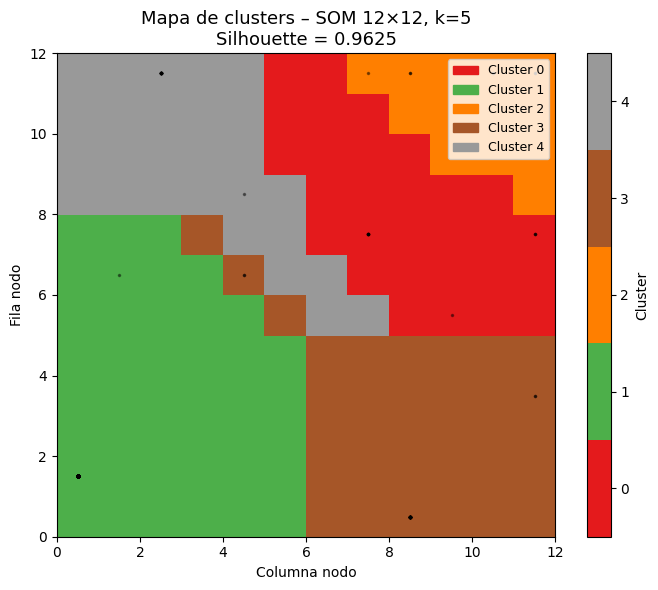

In [31]:
#  Mapa de clusters (nodos coloreados por cluster K-Means)
fig, ax = plt.subplots(figsize=(7, 6))

cluster_map = labels_nodes_best.reshape(best_sz, best_sz)
cmap_disc = plt.colormaps['Set1'].resampled(best_k)
im = ax.pcolor(cluster_map.T, cmap=cmap_disc, vmin=-0.5, vmax=best_k - 0.5)
plt.colorbar(im, ax=ax, ticks=range(best_k), label='Cluster')
ax.set_title(f'Mapa de clusters – SOM {best_sz}×{best_sz}, k={best_k}\nSilhouette = {best_row["Silhouette"]:.4f}', fontsize=13)
ax.set_xlabel('Columna nodo')
ax.set_ylabel('Fila nodo')

# Superponer activaciones de pacientes
for x, label in zip(X_best, labels_best):
    w = best_som.winner(x)
    ax.plot(w[0] + 0.5, w[1] + 0.5, '.', color='black', markersize=3, alpha=0.4)

handles = [mpatches.Patch(color=cmap_disc(i), label=f'Cluster {i}') for i in range(best_k)]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

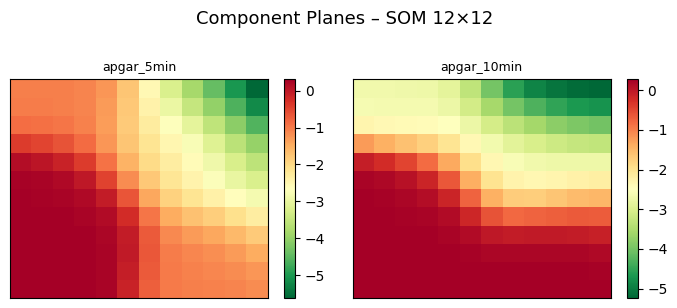

In [32]:
#  Component planes (una variable por panel)
n_vars = len(vars_best)
ncols = min(4, n_vars)
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes = np.array(axes).reshape(-1)

weights = best_som.get_weights()  # (n_rows, n_cols, n_features)

for i, var in enumerate(vars_best):
    ax = axes[i]
    plane = weights[:, :, i].T
    im = ax.pcolor(plane, cmap='RdYlGn_r')
    plt.colorbar(im, ax=ax)
    ax.set_title(var, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# Ocultar ejes vacíos
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Component Planes – SOM {best_sz}×{best_sz}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

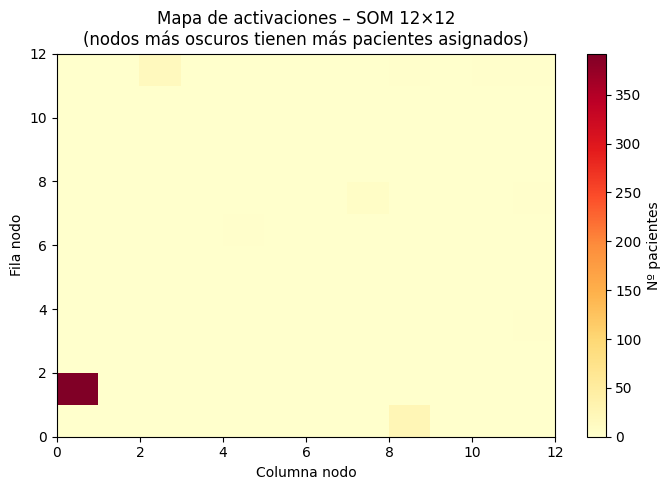

In [33]:
# Histograma de activaciones (nodos más populares)
fig, ax = plt.subplots(figsize=(7, 5))
freq_map = best_som.activation_response(X_best).T
im = ax.pcolor(freq_map, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Nº pacientes')
ax.set_title(f'Mapa de activaciones – SOM {best_sz}×{best_sz}\n(nodos más oscuros tienen más pacientes asignados)', fontsize=12)
ax.set_xlabel('Columna nodo')
ax.set_ylabel('Fila nodo')
plt.tight_layout()
plt.show()

# 8. Descripción de clusters

Igual que en reunion8: media±DT para numéricas, frecuencia para categóricas.

In [34]:
# Construir df_maestro
df_imp_clust['id'] = df_imp_clust['id'].astype(float)
df_cat['ID'] = df_cat['ID'].astype(float)
df_eco['id'] = df_eco['id'].astype(float)

vars_embarazo = [c for c in [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri', 'eg_parto',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min'
] if c in df_imp_clust.columns]

vars_biomarcadores = [c for c in ['ratio_MoM', 'sflt1_MoM', 'plgf_MoM'] if c in df_imp_clust.columns]

# Unir eco y scores al dataset principal
df_maestro = pd.merge(df_imp_clust, df_eco[['id'] + vars_eco], on='id', how='left')
df_maestro = pd.merge(df_maestro, df_cat, left_on='id', right_on='ID', how='left')

cols_cat_scores = ['Cat_Dieta', 'Cat_Actividad', 'Cat_Estres', 'Cat_Memoria', 'Cat_SCL90R']

print(f'df_maestro: {df_maestro.shape}')

df_maestro: (459, 74)


In [35]:
def describir_clusters(df, variables_num, variables_cat):
    """Tabla descriptiva por cluster: media±DT para numéricas, % para categóricas."""
    partes = []
    if variables_num:
        res_num = df.groupby('cluster')[variables_num].agg(
            lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
        ).T
        res_num.columns = [f"Grupo {i}" for i in res_num.columns]
        partes.append(res_num)
    if variables_cat:
        cat_list = []
        for col in variables_cat:
            valid = df[[col, 'cluster']].dropna(subset=[col])
            ct = pd.crosstab(valid[col], valid['cluster'], normalize='columns') * 100
            ct.index = [f"{col}: {idx}" for idx in ct.index]
            cat_list.append(ct.map(lambda x: f"{x:.1f}%"))
        res_cat = pd.concat(cat_list)
        res_cat.columns = [f"Grupo {i}" for i in res_cat.columns]
        partes.append(res_cat)
    return pd.concat(partes) if partes else pd.DataFrame()


grupos_informe = {
    "GESTACIÓN Y BIOMARCADORES": vars_embarazo + vars_biomarcadores,
    "ECOCARDIOGRAFÍA": vars_eco,
    "SCORES CATEGÓRICOS": cols_cat_scores
}

In [36]:
# Descripción del mejor resultado
ids_best = df_num['id'].values
mapa_clusters = pd.DataFrame({'id': ids_best, 'cluster': labels_best})

df_desc = df_maestro.drop(columns=['cluster'], errors='ignore')
df_desc = pd.merge(df_desc, mapa_clusters, on='id', how='inner')

print(f'MEJOR SOM: {best_sz}×{best_sz}  |  k={best_k}  |  Silhouette={best_row["Silhouette"]:.4f}')
print(f'Variables de clustering: {vars_best}\n')

tamanos = df_desc['cluster'].value_counts().sort_index()
tamanos.index = [f'Grupo {i}' for i in tamanos.index]
print('TAMAÑO DE LOS GRUPOS')
print(tamanos.to_frame(name='N').T.to_string())

for nombre_bloque, vars_bloque in grupos_informe.items():
    v_num = [v for v in vars_bloque if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])]
    v_cat = [v for v in vars_bloque if v in df_desc.columns and not pd.api.types.is_numeric_dtype(df_desc[v])]
    if v_num or v_cat:
        print(f'\n{nombre_bloque}')
        tabla = describir_clusters(df_desc, v_num, v_cat)
        display(tabla)

MEJOR SOM: 12×12  |  k=5  |  Silhouette=0.9625
Variables de clustering: ['apgar_5min', 'apgar_10min']

TAMAÑO DE LOS GRUPOS
   Grupo 0  Grupo 1  Grupo 2  Grupo 3  Grupo 4
N       11      393        7       30       17

GESTACIÓN Y BIOMARCADORES


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
peso_ini_gest,71.95 ± 22.09,66.43 ± 14.40,74.90 ± 14.63,66.92 ± 13.30,69.97 ± 13.80
peso_fin_gest,84.95 ± 23.21,78.03 ± 14.98,89.50 ± 13.80,79.19 ± 14.05,81.14 ± 15.09
aumento_peso_gest,12.90 ± 4.55,11.60 ± 5.34,14.73 ± 10.76,12.18 ± 6.34,11.37 ± 4.99
talla,159.27 ± 5.02,163.93 ± 6.20,162.50 ± 4.77,164.21 ± 6.14,163.35 ± 5.79
imc_ini_gest,28.59 ± 9.65,24.69 ± 5.02,28.05 ± 4.88,24.83 ± 4.51,26.20 ± 4.73
edad_materna_gest,37.26 ± 5.34,35.27 ± 4.59,36.30 ± 3.22,37.69 ± 5.40,36.38 ± 4.47
tas_1tri,127.26 ± 12.19,113.40 ± 10.93,115.62 ± 8.08,118.95 ± 14.49,118.62 ± 14.26
tad_1tri,81.95 ± 14.18,72.48 ± 7.84,79.75 ± 4.68,75.63 ± 10.16,73.03 ± 7.66
eg_eco_1tri,12.81 ± 0.53,12.73 ± 0.62,12.64 ± 0.41,12.75 ± 0.54,12.84 ± 0.40
eg_parto,35.85 ± 3.50,39.39 ± 1.58,33.30 ± 4.32,38.09 ± 2.66,36.66 ± 4.07



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
diam_telediastolico,43.33 ± 4.95,44.93 ± 5.57,45.20 ± 4.09,45.63 ± 3.90,45.31 ± 5.68
diam_telesistolico,27.00 ± 4.65,29.94 ± 4.55,31.40 ± 3.91,29.90 ± 4.30,29.32 ± 4.24
dtsvi_indexado,14.99 ± 2.73,16.99 ± 2.75,16.68 ± 3.27,16.73 ± 2.90,16.50 ± 2.70
septo_iv_diastole,9.94 ± 2.07,9.10 ± 8.53,8.94 ± 0.92,10.73 ± 13.33,13.92 ± 22.03
pared_posterior_vi_diastole,7.56 ± 1.18,8.35 ± 8.02,8.10 ± 1.20,9.81 ± 11.98,11.84 ± 14.53
diam_ai,34.00 ± 3.78,33.26 ± 4.66,34.20 ± 3.96,33.60 ± 3.87,35.83 ± 5.92
ai_volumen,37.71 ± 17.11,36.93 ± 13.59,42.12 ± 8.10,35.75 ± 8.06,41.13 ± 11.30
ad_volumen,30.94 ± 10.54,32.62 ± 15.85,41.50 ± 21.11,34.11 ± 10.09,31.41 ± 10.92
tapse,26.97 ± 3.78,26.08 ± 18.12,26.00 ± 4.53,25.26 ± 3.03,26.28 ± 4.27
e_mitral,71.59 ± 18.34,80.06 ± 65.09,72.92 ± 13.78,71.50 ± 13.93,79.22 ± 15.98



SCORES CATEGÓRICOS


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
Cat_Dieta: Adherencia moderada,72.7%,61.8%,57.1%,60.0%,64.7%
Cat_Dieta: Alta adherencia,0.0%,5.6%,0.0%,10.0%,0.0%
Cat_Dieta: Baja adherencia,27.3%,32.6%,42.9%,30.0%,35.3%
Cat_Actividad: Actividad física alta,100.0%,91.0%,100.0%,86.7%,94.1%
Cat_Actividad: Actividad física baja,0.0%,2.8%,0.0%,0.0%,0.0%
Cat_Actividad: Actividad física moderada,0.0%,6.2%,0.0%,13.3%,5.9%
Cat_Estres: Nivel de estrés alto,20.0%,35.2%,14.3%,36.7%,52.9%
Cat_Estres: Nivel de estrés bajo,30.0%,12.0%,0.0%,6.7%,0.0%
Cat_Estres: Nivel de estrés moderado,30.0%,49.7%,85.7%,53.3%,47.1%
Cat_Estres: Nivel de estrés muy alto,20.0%,3.1%,0.0%,3.3%,0.0%


# 9. Descripción de TODAS las combinaciones top

Para cada combinación del top3 y su mejor tamaño de SOM.

In [37]:
# Para cada combinación, seleccionar el tamaño con mejor Silhouette
for ci in range(len(top_combis)):
    # Buscar el mejor (tamaño, k) para esta combinación
    subset_sil = df_sil[df_sil['combi'] == ci + 1].dropna(subset=['Silhouette'])
    if subset_sil.empty:
        continue
    best_sub = subset_sil.sort_values('Silhouette', ascending=False).iloc[0]
    ci_sz  = int(best_sub['size'])
    ci_k   = int(best_sub['k'])
    ci_som = trained_soms[(ci, ci_sz)]
    X_sc, _, vars_c = scaled_subsets[ci]
    labels_ci, _ = cluster_som_nodes(ci_som, X_sc, ci_k)

    ids_ci = df_num['id'].values
    mapa_ci = pd.DataFrame({'id': ids_ci, 'cluster': labels_ci})
    df_ci = df_maestro.drop(columns=['cluster'], errors='ignore')
    df_ci = pd.merge(df_ci, mapa_ci, on='id', how='inner')

    tam = df_ci['cluster'].value_counts().sort_index()
    tam.index = [f'Grupo {i}' for i in tam.index]

    print(f'COMBINACIÓN {ci+1}  |  SOM {ci_sz}×{ci_sz}  |  k={ci_k}  |  Silhouette={best_sub["Silhouette"]:.4f}')
    print(f'Variables: {vars_c}')
    print('\nTAMAÑO DE LOS GRUPOS')
    print(tam.to_frame(name='N').T.to_string())

    for nombre_bloque, vars_bloque in grupos_informe.items():
        v_num = [v for v in vars_bloque if v in df_ci.columns and pd.api.types.is_numeric_dtype(df_ci[v])]
        v_cat = [v for v in vars_bloque if v in df_ci.columns and not pd.api.types.is_numeric_dtype(df_ci[v])]
        if v_num or v_cat:
            print(f'\n{nombre_bloque}')
            display(describir_clusters(df_ci, v_num, v_cat))
    print()

COMBINACIÓN 1  |  SOM 12×12  |  k=5  |  Silhouette=0.9625
Variables: ['apgar_5min', 'apgar_10min']

TAMAÑO DE LOS GRUPOS
   Grupo 0  Grupo 1  Grupo 2  Grupo 3  Grupo 4
N       11      393        7       30       17

GESTACIÓN Y BIOMARCADORES


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
peso_ini_gest,71.95 ± 22.09,66.43 ± 14.40,74.90 ± 14.63,66.92 ± 13.30,69.97 ± 13.80
peso_fin_gest,84.95 ± 23.21,78.03 ± 14.98,89.50 ± 13.80,79.19 ± 14.05,81.14 ± 15.09
aumento_peso_gest,12.90 ± 4.55,11.60 ± 5.34,14.73 ± 10.76,12.18 ± 6.34,11.37 ± 4.99
talla,159.27 ± 5.02,163.93 ± 6.20,162.50 ± 4.77,164.21 ± 6.14,163.35 ± 5.79
imc_ini_gest,28.59 ± 9.65,24.69 ± 5.02,28.05 ± 4.88,24.83 ± 4.51,26.20 ± 4.73
edad_materna_gest,37.26 ± 5.34,35.27 ± 4.59,36.30 ± 3.22,37.69 ± 5.40,36.38 ± 4.47
tas_1tri,127.26 ± 12.19,113.40 ± 10.93,115.62 ± 8.08,118.95 ± 14.49,118.62 ± 14.26
tad_1tri,81.95 ± 14.18,72.48 ± 7.84,79.75 ± 4.68,75.63 ± 10.16,73.03 ± 7.66
eg_eco_1tri,12.81 ± 0.53,12.73 ± 0.62,12.64 ± 0.41,12.75 ± 0.54,12.84 ± 0.40
eg_parto,35.85 ± 3.50,39.39 ± 1.58,33.30 ± 4.32,38.09 ± 2.66,36.66 ± 4.07



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
diam_telediastolico,43.33 ± 4.95,44.93 ± 5.57,45.20 ± 4.09,45.63 ± 3.90,45.31 ± 5.68
diam_telesistolico,27.00 ± 4.65,29.94 ± 4.55,31.40 ± 3.91,29.90 ± 4.30,29.32 ± 4.24
dtsvi_indexado,14.99 ± 2.73,16.99 ± 2.75,16.68 ± 3.27,16.73 ± 2.90,16.50 ± 2.70
septo_iv_diastole,9.94 ± 2.07,9.10 ± 8.53,8.94 ± 0.92,10.73 ± 13.33,13.92 ± 22.03
pared_posterior_vi_diastole,7.56 ± 1.18,8.35 ± 8.02,8.10 ± 1.20,9.81 ± 11.98,11.84 ± 14.53
diam_ai,34.00 ± 3.78,33.26 ± 4.66,34.20 ± 3.96,33.60 ± 3.87,35.83 ± 5.92
ai_volumen,37.71 ± 17.11,36.93 ± 13.59,42.12 ± 8.10,35.75 ± 8.06,41.13 ± 11.30
ad_volumen,30.94 ± 10.54,32.62 ± 15.85,41.50 ± 21.11,34.11 ± 10.09,31.41 ± 10.92
tapse,26.97 ± 3.78,26.08 ± 18.12,26.00 ± 4.53,25.26 ± 3.03,26.28 ± 4.27
e_mitral,71.59 ± 18.34,80.06 ± 65.09,72.92 ± 13.78,71.50 ± 13.93,79.22 ± 15.98



SCORES CATEGÓRICOS


...

,Grupo 0,Grupo 1
peso_ini_gest,71.27 ± 16.68,66.43 ± 14.27
peso_fin_gest,83.38 ± 17.62,78.10 ± 14.87
aumento_peso_gest,12.20 ± 6.04,11.66 ± 5.43
talla,162.34 ± 5.43,163.93 ± 6.21
imc_ini_gest,27.05 ± 6.51,24.70 ± 4.97
edad_materna_gest,37.27 ± 4.50,35.37 ± 4.66
tas_1tri,119.32 ± 13.13,113.85 ± 11.31
tad_1tri,76.88 ± 10.27,72.68 ± 8.03
eg_eco_1tri,12.75 ± 0.59,12.74 ± 0.61
eg_parto,35.61 ± 3.89,39.35 ± 1.62



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1
diam_telediastolico,44.77 ± 4.79,44.97 ± 5.49
diam_telesistolico,28.84 ± 4.23,29.96 ± 4.54
dtsvi_indexado,15.77 ± 2.96,17.00 ± 2.73
septo_iv_diastole,11.18 ± 14.20,9.23 ± 9.00
pared_posterior_vi_diastole,9.30 ± 9.49,8.48 ± 8.41
diam_ai,35.11 ± 4.70,33.25 ± 4.61
ai_volumen,39.22 ± 12.32,36.89 ± 13.30
ad_volumen,33.32 ± 12.73,32.71 ± 15.54
tapse,26.20 ± 3.97,26.04 ± 17.55
e_mitral,75.34 ± 16.14,79.48 ± 63.02



SCORES CATEGÓRICOS


,Grupo 0,Grupo 1
Cat_Dieta: Adherencia moderada,65.0%,61.7%
Cat_Dieta: Alta adherencia,2.5%,5.7%
Cat_Dieta: Baja adherencia,32.5%,32.5%
Cat_Actividad: Actividad física alta,94.7%,90.8%
Cat_Actividad: Actividad física baja,0.0%,2.7%
Cat_Actividad: Actividad física moderada,5.3%,6.5%
Cat_Estres: Nivel de estrés alto,38.5%,35.0%
Cat_Estres: Nivel de estrés bajo,7.7%,11.8%
Cat_Estres: Nivel de estrés moderado,48.7%,50.1%
Cat_Estres: Nivel de estrés muy alto,5.1%,3.1%


# 10. Comparación SOM vs K-Means (reunion8)

| Método | Mejor Silhouette | k | Variables |
|--------|-----------------|---|----------|
| K-Means (reunion8) | 0.8215 | 2 | peso_ini_gest, ratio_MoM |
| SOM | 0.96253 | 5 | apgar_5min, apgar_10min |

In [38]:
# K-Means (reunion8) - resultados conocidos
kmeans_results = [
    {'Método': 'K-Means', 'k': 2, 'Silhouette': 0.8215, 'Variables': "['peso_ini_gest', 'ratio_MoM']",
     'Nota': 'Distribución: 450 vs 8 pacientes'},
    {'Método': 'K-Means', 'k': 3, 'Silhouette': 0.6052, 'Variables': "['peso_ini_gest', 'ratio_MoM']",
     'Nota': ''},
    {'Método': 'K-Means', 'k': 4, 'Silhouette': 0.5954, 'Variables': "['peso_ini_gest', 'ratio_MoM']",
     'Nota': ''},
]
df_kmeans = pd.DataFrame(kmeans_results)

# SOM - mejores resultados
som_top = df_sil.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).head(5).copy()
som_top['Método'] = 'SOM'
som_top['Variables'] = som_top['variables'].apply(str)
som_top['Nota'] = som_top['distribución'].apply(str)
som_top_display = som_top[['Método', 'tamaño', 'k', 'Silhouette', 'Variables', 'Nota']]

print('\nK-Means (reunion8):')
display(df_kmeans[['Método', 'k', 'Silhouette', 'Variables', 'Nota']])

print('\nSOM (top 5):')
display(som_top_display)

print('\nRESUMEN:')
print(f'  K-Means mejor Silhouette: 0.8215 (k=2, 2 variables)')
best_som_sil = df_sil.dropna(subset=['Silhouette'])['Silhouette'].max()
best_som_row = df_sil.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print(f'  SOM mejor Silhouette    : {best_som_sil:.4f} (k={best_som_row["k"]}, tamaño={best_som_row["tamaño"]}, {len(best_som_row["variables"])} vars)')


K-Means (reunion8):


,Método,k,Silhouette,Variables,Nota
0,K-Means,2,0.8215,"['peso_ini_gest', 'ratio_MoM']",Distribución: 450 vs 8 pacientes
1,K-Means,3,0.6052,"['peso_ini_gest', 'ratio_MoM']",
2,K-Means,4,0.5954,"['peso_ini_gest', 'ratio_MoM']",



SOM (top 5):


,Método,tamaño,k,Silhouette,Variables,Nota
11,SOM,12×12,5,0.96253,"['apgar_5min', 'apgar_10min']","{'G0': 11, 'G1': 393, 'G2': 7, 'G3': 30, 'G4': 17}"
3,SOM,8×8,5,0.95997,"['apgar_5min', 'apgar_10min']","{'G0': 18, 'G1': 28, 'G2': 10, 'G3': 7, 'G4': 395}"
7,SOM,10×10,5,0.95997,"['apgar_5min', 'apgar_10min']","{'G0': 18, 'G1': 395, 'G2': 7, 'G3': 28, 'G4': 10}"
10,SOM,12×12,4,0.95406,"['apgar_5min', 'apgar_10min']","{'G0': 30, 'G1': 393, 'G2': 10, 'G3': 25}"
6,SOM,10×10,4,0.95404,"['apgar_5min', 'apgar_10min']","{'G0': 395, 'G1': 25, 'G2': 10, 'G3': 28}"



RESUMEN:
  K-Means mejor Silhouette: 0.8215 (k=2, 2 variables)
  SOM mejor Silhouette    : 0.9625 (k=5, tamaño=12×12, 2 vars)
